# Part 2. Pipeline · Data Leakage · CV 분할 비교

---
## 0. 환경 설정 및 데이터


### 문제 1. 라이브러리 및 tips 준비

**[개념 및 논문 리뷰]**
Pipeline·CV·통계 검정용 패키지를 임포트합니다.


In [1]:
import sys

# 1. OS 환경 확인 및 리눅스 환경일 경우 나눔 폰트 재설치/캐시 초기화
if sys.platform != 'darwin':  # macOS가 아닌 환경(Colab 등)
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 2. 기본 데이터 핸들링 및 시각화 라이브러리 로드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats  # 통계 분석 및 확률 분포 계산을 위한 사이파이 모듈

# 3. 사이킷런(Scikit-learn) 실전 모델링 및 검증 라이브러리 로드
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score  # 데이터 분할 및 교차 검증(CV)
from sklearn.preprocessing import StandardScaler                                              # 특성 스케일링 (평균 0, 표준편차 1)
from sklearn.pipeline import Pipeline                                                         # 전처리+모델 학습 프로세스 자동화 (Data Leakage 방지)
from sklearn.linear_model import Ridge                                                        # L2 규제가 적용된 선형 회귀 모델
from sklearn.metrics import mean_squared_error                                                # 모델 평가를 위한 MSE 지표

# 4. 불필요한 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 5. 맷플롯립 내장 폰트 매니저에 나눔 폰트 추가
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# 6. 시각화(글꼴, 음수 기호, 해상도 등) 환경 설정
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# 7. 재현성을 위한 난수 시드(Seed) 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

### 데이터 가져오기

In [2]:
# 8. 데이터 로드 및 파생 변수('bill_per_person') 생성
tips = sns.load_dataset('tips')
df = tips.copy()
df.loc[:, 'bill_per_person'] = df.loc[:, 'total_bill'] / df.loc[:, 'size']

# 9. 모델링에 사용할 특성(Feature)과 타겟(Target) 분리
# 다중 공선성 위험이 조금 보이지만 실험을 위해 3개의 컬럼을 특성으로 지정합니다.
feature_cols = ['total_bill', 'size', 'bill_per_person']
X = df.loc[:, feature_cols].values # 2차원 독립변수 배열
y = df.loc[:, 'tip'].values        # 1차원 종속변수 배열

# 10. 준비 완료 메시지 및 데이터 차원(Shape) 확인
print('Part 2 준비 완료 — X shape', X.shape)

Part 2 준비 완료 — X shape (244, 3)


---
## 1. Data Leakage — 잘못된 예 vs 올바른 Pipeline


### 문제 2. [잘못된 예] 전체 데이터 스케일링 후 Train/Test 분리

**[개념 및 잘못된 예시]**
```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # 전체 fit — 누수!
X_train, X_test = train_test_split(X_scaled, y)
```
- 테스트 분포가 scaler에 반영되어 **치팅**과 같습니다.
- **Data Leakage**: 테스트 정보가 scaler `fit`에 포함 → test RMSE **과소 추정**.


In [3]:
# 1. 데이터 누수 발생 지점
# 테스트 데이터가 분리되기 전에 전체 데이터(X)의 평균과 표준편차를 계산하고 변환합니다.
# 이로 인해 테스트 데이터의 정보가 학습용 스케일러에 '유출(Leakage)'됩니다.
scaler_leak = StandardScaler()
X_scaled_all = scaler_leak.fit_transform(X)

# 2. 데이터 분할
# 이미 누수가 발생한 데이터셋(X_scaled_all)을 학습용과 테스트용으로 분리합니다.
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled_all, y, test_size=0.3, random_state=RANDOM_STATE
)

# 3. 모델 학습
# 유출된 데이터로 정규화된 X_tr를 사용하여 Ridge 회귀 모델을 학습시킵니다.
model_leak = Ridge(alpha=1.0, random_state=RANDOM_STATE)
model_leak.fit(X_tr, y_tr)

# 4. 성능 평가 및 출력
# 실제 운영 환경보다 치우치거나 지나치게 낙관적인(좋은) RMSE 결과가 나올 수 있습니다.
rmse_leak = np.sqrt(mean_squared_error(y_te, model_leak.predict(X_te)))
print(f'[누수] Test RMSE: {rmse_leak:.4f}')

[누수] Test RMSE: 0.9203


### 문제 3. [올바른 예] Pipeline — train에서만 fit

**[개념 및 논문 리뷰]**
**Pipeline** = `(StandardScaler → Ridge)` 한 객체.

**필수 이유**
1. CV fold마다 scaler **re-fit** → 누수 차단
2. 배포 시 train 통계만 저장
3. Grid/Random Search와 **자연스럽게 결합**


In [4]:
# 1. 파이프라인(Pipeline) 구축
# 전처리(Scaler)와 모델(Ridge)을 하나로 묶어 체인을 만듭니다.
# 학습(fit) 시 스케일러가 오직 학습 데이터의 통계량만 사용하도록 강제하여 데이터 누수를 원천 차단합니다.
pipe_clean = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

# 2. 올바른 순서의 데이터 분할
# 원본 데이터(X, y)를 먼저 학습용과 테스트용으로 안전하게 분리합니다.
X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

# 3. 파이프라인 학습
# 내부 동작: X_tr_raw를 scaler.fit_transform()한 후, 그 결과로 model.fit()을 수행합니다.
pipe_clean.fit(X_tr_raw, y_tr)

# 4. 예측 및 성능 평가
# 내부 동작: X_te_raw를 학습 때 사용한 스케일러로 scaler.transform()만 수행한 뒤 model.predict()로 넘깁니다.
rmse_clean = np.sqrt(mean_squared_error(y_te, pipe_clean.predict(X_te_raw)))
print(f'[정상] Test RMSE: {rmse_clean:.4f}')

# 5. 데이터 누수 효과 확인
# 정상적인 평가 결과와 누수가 있었던 결과의 차이를 출력합니다.
# 일반적으로 누수가 있으면 성능이 과도하게 좋게 나오므로(RMSE가 낮게 나옴), 이 차이는 양수(+)로 나올 확률이 높습니다.
print(f'차이 (정상-누수): {rmse_clean - rmse_leak:+.4f}')

[정상] Test RMSE: 0.9203
차이 (정상-누수): -0.0001


### 문제 4. CV 내부 Pipeline — cross_val_score

- 5-Fold CV — fold마다 scaler train-only fit.


In [5]:
# 1. 5-Fold 교차 검증 수행
# 전체 데이터(X, y)를 5개의 폴드로 나누어 내부적으로 파이프라인의 fit 및 evaluate를 반복합니다.
# 'neg_root_mean_squared_error'는 사이킷런의 규칙(클수록 좋은 평가지표)에 따라 RMSE에 음수(-)를 붙여 반환합니다.
# n_jobs=-1을 통해 모든 CPU 코어를 사용하여 병렬로 빠르게 계산합니다.
cv_scores = cross_val_score(
    pipe_clean, X, y, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)

# 2. 음수 RMSE를 양수로 변환
# 평가지표 계산을 위해 음수로 반환된 값에 다시 마이너스(-)를 붙여 실제 RMSE 값으로 되돌립니다.
rmse_folds = -cv_scores

# 3. 각 폴드별 결과 출력
# 5번의 검증에서 각각 계산된 RMSE 리스트를 소수점 4자리까지 반환하여 모델의 안정성을 확인합니다.
print('CV RMSE:', rmse_folds.round(4))

# 4. 최종 성능 평균 및 편차 출력
# 5개 RMSE의 평균(mean)으로 모델의 평균 성능을 보고, 표준편차(std)로 모델이 얼마나 일관성 있는지 확인합니다.
print('mean ± std:', rmse_folds.mean().round(4), rmse_folds.std().round(4))

CV RMSE: [0.8823 0.8314 0.901  1.3352 1.1479]
mean ± std: 1.0195 0.192


---
## 2. K-Fold vs Stratified K-Fold


### 문제 5. 연속 타깃 Binning — qcut

- 회귀 `tip`을 5구간 bin → StratifiedKFold label.


tip_bin
0    78
1    20
2    48
3    57
4    41
Name: count, dtype: int64


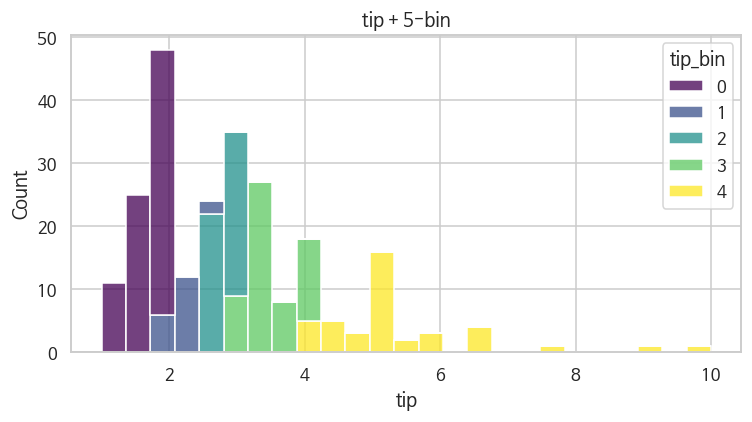

In [9]:
# 1. 분위수 기준 구간화 (Quantile Binning)
# 'tip' 컬럼의 값을 데이터 개수가 균등하게 5개 구간(q=5)으로 나눕니다.
# labels=False로 설정하여 구간 범위를 문자열로 받는 대신 0, 1, 2, 3, 4의 정수 레이블을 할당합니다.
# duplicates='drop'은 동일한 팁 금액이 많아 구간 경계가 겹칠 경우, 중복된 경계를 제거하여 에러를 방지합니다.
df.loc[:, 'tip_bin'] = pd.qcut(df.loc[:, 'tip'], q=5, labels=False, duplicates='drop')

# 2. 빈도수 확인
# 변환된 'tip_bin'의 구간별 데이터 개수를 확인합니다.
# qcut의 특성상 각 인덱스(0~4)별로 거의 동일한 숫자의 데이터 수가 출력됩니다.
print(df.loc[:, 'tip_bin'].value_counts().sort_index())

# 3. 시각화 설정
fig, ax = plt.subplots(figsize=(7, 4))

# 4. 쌓음 히스토그램(Stacked Histogram) 그리기
# x축은 연속형 팁 금액, hue에는 방금 만든 tip_bin을 지정하여 구간별로 색상을 다르게 칠합니다.
# multiple='stack'을 통해 각 구간이 위로 쌓이는 형태를 취해 전체 분포 속에서 각 빈(Bin)의 영역을 직관적으로 보여줍니다.
# palette='viridis'로 자연스럽고 연속적인 색상 변화를 줍니다.
sns.histplot(data=df, x='tip', hue='tip_bin', multiple='stack', bins=25, ax=ax, palette='viridis')

# 5. 그래프 제목 및 레이아웃 마감
ax.set_title('tip + 5-bin')
plt.tight_layout()
plt.show()

- bin별 표본 균형 — stratify 가능.


### 문제 6. KFold vs StratifiedKFold fold RMSE

- Pipeline 동일, split만 변경.


In [10]:
# 1. StratifiedKFold의 기준으로 사용할 범주형 타깃 추출
y_bin = df.loc[:, 'tip_bin'].values

# 안전하게 격리된 전처리 및 모델 파이프라인
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

# 2. 교차 검증용 RMSE 계산 함수 정의
# 분할기(cv_splitter)와 층화 기준(y_strat)을 받아 각 폴드별 RMSE를 계산합니다.
def fold_rmses(cv_splitter, y_strat=None):
    rmses = []
    # y_strat(y_bin) 유무에 따라 split 메서드에 인자를 다르게 전달합니다.
    splits = cv_splitter.split(X, y_strat) if y_strat is not None else cv_splitter.split(X)

    # 각 폴드의 인덱스를 순회하며 학습 및 평가 진행
    for tr_idx, te_idx in splits:
        # 인덱스를 활용해 해당 폴드의 데이터로 파이프라인 학습
        pipe.fit(X[tr_idx], y[tr_idx])
        # 테스트 폴드 데이터로 RMSE 계산 후 리스트에 추가
        rmses.append(np.sqrt(mean_squared_error(y[te_idx], pipe.predict(X[te_idx]))))

    return np.array(rmses)

# 3. 분할기 객체 생성
# 일반 K-Fold: 단순히 무작위로 데이터를 5개로 나눕니다.
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# 층화 K-Fold: 지정한 그룹(y_bin)의 비율이 5개 폴드에 골고루 들어가도록 나눕니다.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 4. 각각의 분할 방식으로 RMSE 계산
rmse_kf = fold_rmses(kf)
rmse_skf = fold_rmses(skf, y_bin) # 층화 기준으로 y_bin을 전달

# 5. 결과 출력
# 두 방식 간의 폴드별 RMSE 변동성을 비교할 수 있습니다.
print('KFold      :', rmse_kf.round(4))
print('Stratified :', rmse_skf.round(4))

KFold      : [0.8196 1.0646 1.0304 0.9747 1.2424]
Stratified : [1.1484 1.04   0.7527 1.1151 0.9767]


- KFold (1.0263) vs Stratified (1.0066)
- Stratified K-Fold를 사용했을 때 전체적인 평균 RMSE가 소폭 감소(성능 개선)


### 문제 7. CV 방식 Boxplot
- 30 seeds × 5 folds.


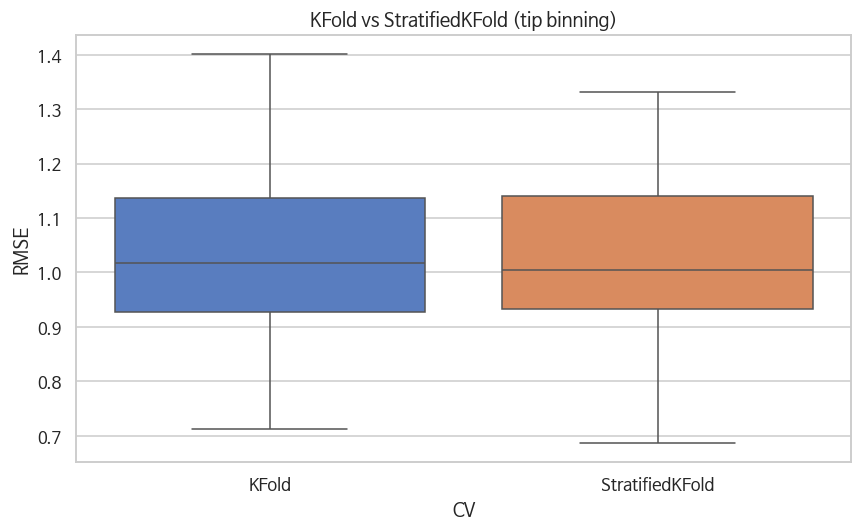

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold

# 1. 결과를 누적할 리스트 초기화
records = []

# 2. 30개의 서로 다른 시드(Seed)로 대규모 반복 실험 진행
# 총 30번의 분할 규칙을 바꾸며 실험하므로, 각각 5-Fold인 두 방식은 총 150개씩(30 * 5)의 RMSE 값을 얻게 됩니다.
for seed in range(30):
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    skf_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    # 일반 KFold의 5개 폴드별 RMSE를 기록 (y_strat 없이 진행)
    for v in fold_rmses(kf_s):
        records.append({'CV': 'KFold', 'RMSE': v})

    # 층화 KFold의 5개 폴드별 RMSE를 기록 (y_bin을 기준으로 층화 분할)
    for v in fold_rmses(skf_s, y_bin):
        records.append({'CV': 'StratifiedKFold', 'RMSE': v})

# 3. 데이터프레임 변환
# 시각화 툴(Seaborn)이 인식하기 가장 좋은 형태(Long-form)로 변환합니다.
cv_df = pd.DataFrame(records)

# 4. 박스 플롯(Boxplot) 시각화
fig, ax = plt.subplots(figsize=(8, 5))
# KFold와 StratifiedKFold 그룹 간의 전체적인 RMSE 분포를 한눈에 비교합니다.
sns.boxplot(data=cv_df, x='CV', y='RMSE', ax=ax, palette='muted')

# 그래프 제목 및 레이아웃 설정
ax.set_title('KFold vs StratifiedKFold (tip binning)')
plt.tight_layout()
plt.show()

### 문제 8. Paired t-test

- 30 seeds 평균 fold RMSE 쌍체 비교.


In [13]:
# 1. 30개 시드 실험 진행
paired_kf, paired_skf = [], []
for seed in range(30):
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    skf_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    paired_kf.append(fold_rmses(kf_s).mean())
    paired_skf.append(fold_rmses(skf_s, y_bin).mean())

# 2. 통계적 가설 검정
t_stat, p_val = stats.ttest_rel(paired_kf, paired_skf)
ALPHA = 0.05  # 유의수준 설정

# 3. if 조건문을 통한 검정 결과 해석 및 분기 처리
print(f"=== 통계적 가설 검정 결과 (p-value: {p_val:.4e}) ===")

if p_val < ALPHA:
    # [조건 1] p-value가 0.05 미만인 경우: 두 방식 사이에 유의미한 차이가 있음
    print("[결정] 두 검증 방식 간에 통계적으로 유의미한 성능 차이가 존재합니다.")

    # 두 방식 중 평균 RMSE가 더 낮은(성능이 좋은) 방식을 최종 선택
    if np.mean(paired_skf) < np.mean(paired_kf):
        print("-> 타깃의 분포를 반영하는 'StratifiedKFold'를 최종 검증 전략으로 채택합니다.")
        final_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        use_stratify = True
    else:
        print("-> 무작위 분할인 'KFold'가 통계적으로 더 나은 성능을 보여 채택합니다.")
        final_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        use_stratify = False
else:
    # [조건 2] p-value가 0.05 이상인 경우: 두 방식의 차이가 우연일 확률이 높음 (비등함)
    print("[결정] 두 방식 간의 통계적 차이가 없습니다. (p >= 0.05)")
    print("-> 구현이 단순하고 연산이 효율적인 일반 'KFold'를 최종 검증 전략으로 채택합니다.")
    final_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    use_stratify = False

print("=" * 50)

# 4. 결정된 final_cv로 최종 교차 검증 수행
# 위에서 결정된 분기(use_stratify)에 따라 적절한 인자를 전달합니다.
if use_stratify:
    final_scores = fold_rmses(final_cv, y_bin)
else:
    final_scores = fold_rmses(final_cv)

print(f"최종 채택된 방식의 5-Fold RMSE 평균: {final_scores.mean():.4f}")

=== 통계적 가설 검정 결과 (p-value: 6.2291e-01) ===
[결정] 두 방식 간의 통계적 차이가 없습니다. (p >= 0.05)
-> 구현이 단순하고 연산이 효율적인 일반 'KFold'를 최종 검증 전략으로 채택합니다.
최종 채택된 방식의 5-Fold RMSE 평균: 1.0263


### 문제 9. diamonds Pipeline

- Seaborn diamonds `price` 회귀 CV.


In [15]:
# 1. 데이터 로드 및 필요한 특성(Feature) 추출
diamonds = sns.load_dataset('diamonds')
dia = diamonds.loc[:, ['carat', 'depth', 'table', 'price']].copy()

# 2. 파생 변수 생성 (Feature Engineering)
# 캐럿과 깊이를 곱해 다이아몬드의 대략적인 '부피'를 대변하는 새로운 특성을 만듭니다.
dia.loc[:, 'volume_proxy'] = dia.loc[:, 'carat'] * dia.loc[:, 'depth']

# 3. 입력 데이터(Xd)와 타깃 데이터(yd) 분리
Xd = dia.loc[:, ['carat', 'depth', 'table', 'volume_proxy']].values
yd = dia.loc[:, 'price'].values

# 4. 안전한 전처리+모델 파이프라인 구축
# 교차 검증 시 데이터 누수(Data Leakage)를 방지하기 위해 스케일러와 Ridge 모델을 묶습니다.
pipe_d = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# 5. 3-Fold 교차 검증 수행
# 내부적으로 스케일링이 폴드마다 독립적으로 적용되며, RMSE 결과에 음수가 붙어 나오므로 마이너스(-)를 붙여 양수로 변환합니다.
scores_d = -cross_val_score(pipe_d, Xd, yd, cv=3, scoring='neg_root_mean_squared_error')

# 6. 결과 출력
print('diamonds CV RMSE:', scores_d.round(2))


diamonds CV RMSE: [1744.37 3210.89  791.63]
